# Laboratório de precisão — comportamento sob tarifa real da Enel

Bancada para **visualizar** se o agente aprende a antecipar o posto de ponta
(17h30–20h30, R$ 1,480/kWh) mantendo tolerância estreita.

A pergunta: o PI atinge 97,3 % dentro de ±0,5 °C mas paga R$ 4,72 no pico. Uma
política antecipatória crua corta 44 % desse custo e cai a 72 % de tolerância.
**Quanto o DQN captura sem perder precisão?**

Figuras salvas em `plots_lab/`.


In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath(".."))
import numpy.core
for sub in ("", ".numeric", ".multiarray", ".umath", "._multiarray_umath"):
    try:
        __import__("numpy.core" + sub); sys.modules["numpy._core" + sub] = sys.modules["numpy.core" + sub]
    except Exception: pass

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from stable_baselines3 import DQN

from config import config_for_lab, LAB_PROFILES
from env import ClassroomACEnv
from wrappers import ActionRepeatWrapper
from baselines import PIController
from ac_physics import ACState
from metrics import run_episode, episode_metrics

SAVE = "../plots_lab"; os.makedirs(SAVE, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

CFG = config_for_lab("Lab_Equilibrado")
SETP, TOL = CFG.ideal_temp, CFG.lab_tolerance
# Cenário-chave: sala cheia atravessando o posto de ponta.
CEN = {"start_temp": 24.0, "occupancy": 45, "hour": 12, "name": "lab_pico"}

CORES = {"PI": "#e05561", "Pré-cooling": "#8c6bb1",
         "Lab_Precisao": "#2b7bba", "Lab_Equilibrado": "#4daf4a", "Lab_Economico": "#e8801a"}

class PreCool:
    def reset(self): pass
    def predict(self, obs, deterministic=True, info=None):
        t, h = info["temperature"], info["hour_float"] % 24
        if 15.5 <= h < 17.5: return int(ACState.MEDIUM if t > SETP - TOL else ACState.OFF), None
        if 17.5 <= h < 20.5: return int(ACState.OFF if t < SETP + TOL else ACState.LOW), None
        if t > SETP + TOL*0.5: return int(ACState.MEDIUM), None
        return int(ACState.OFF), None

def fab(cfg=CFG): return ActionRepeatWrapper(ClassroomACEnv(config=cfg), repeat=2)

# Coleta trajetórias
traj, cfgs = {}, {}
for nome, ag in [("PI", PIController(CFG, kp=1.3, ki=0.2)), ("Pré-cooling", PreCool())]:
    traj[nome] = run_episode(ag, fab(), CEN, seed=0, pass_info_to_agent=True); cfgs[nome] = CFG
for path in sorted(glob.glob("../models_lab/DQN_Lab_*_seed0.zip")):
    perfil = os.path.basename(path).replace("DQN_", "").replace("_seed0.zip", "")
    c = config_for_lab(perfil)
    traj[perfil] = run_episode(DQN.load(path, device="cpu"), fab(c), CEN, seed=0); cfgs[perfil] = c

print(f"tarifa: {CFG.tariff.name}")
print(f"tolerância: {SETP} ± {TOL} °C | trajetórias: {list(traj)}")

tarifa: Enel SP — Tarifa Branca B1
tolerância: 24.0 ± 0.5 °C | trajetórias: ['PI', 'Pré-cooling', 'Lab_Economico', 'Lab_Equilibrado', 'Lab_Precisao']


## 1. A figura principal — trajetória sobre os postos tarifários

Se o agente aprendeu a antecipar, a temperatura deve **descer antes de 17h30** e
subir dentro da tolerância durante a faixa vermelha, com o AC desligado.


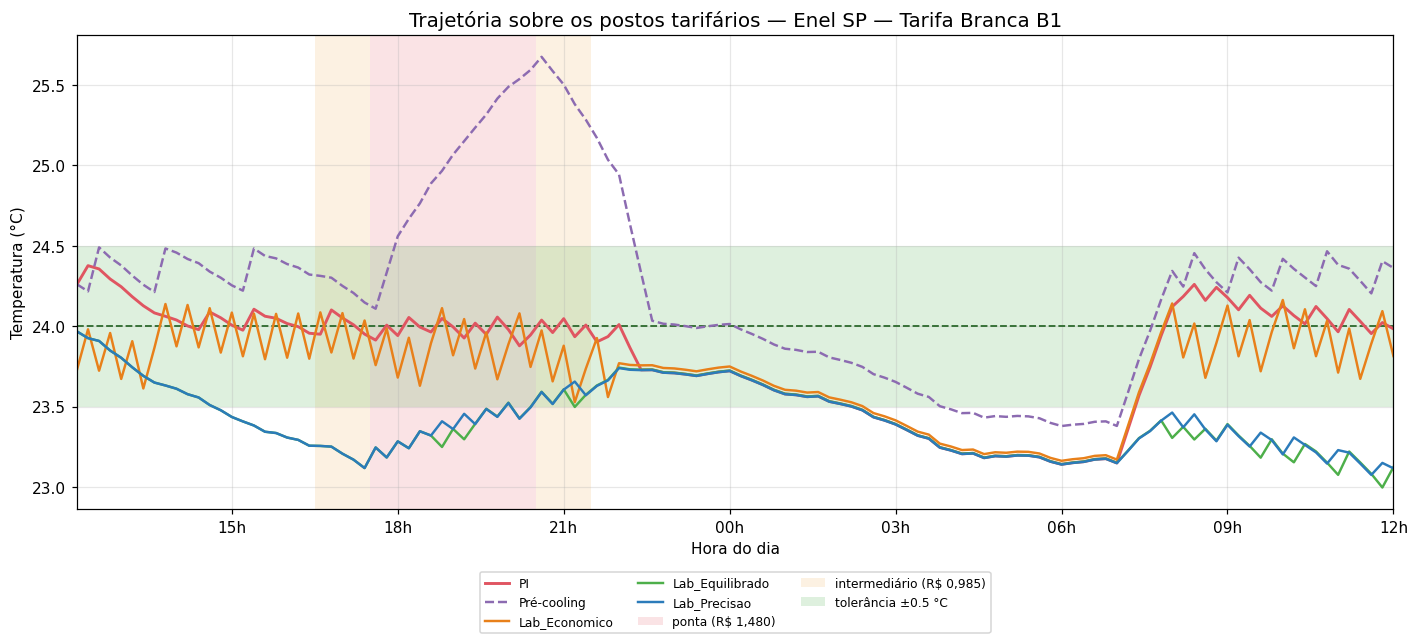

In [2]:
def faixas_tarifa(ax, cfg, h0, h1):
    """
    Pinta os postos tarifarios. O eixo e horas DESDE O INICIO do episodio; os
    rotulos mostram hora do dia (mod 24). Plotar hour_float cru levava o eixo a
    36h num episodio que comeca as 12h, escondendo que o dia cicla.
    """
    t = cfg.tariff
    for h in np.arange(np.floor(h0), np.ceil(h1), 0.5):
        cor = {"ponta": "#e05561", "intermediario": "#f0ad4e"}.get(t.posto(h))
        if cor: ax.axvspan(h, h + 0.5, color=cor, alpha=0.16, lw=0)

def eixo_hora_do_dia(ax, h0, h1):
    """Rotula o eixo X com a hora do dia, ciclando em 24h."""
    ticks = np.arange(np.ceil(h0/3)*3, h1 + 0.1, 3)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(t)%24:02d}h" for t in ticks])
    ax.set_xlim(h0, h1)

fig, ax = plt.subplots(figsize=(13, 6))
h0 = traj["PI"]["hour_float"].min(); h1 = traj["PI"]["hour_float"].max()
faixas_tarifa(ax, CFG, h0, h1)
ax.axhspan(SETP - TOL, SETP + TOL, color="#4daf4a", alpha=0.18, lw=0)
ax.axhline(SETP, color="#2f6b2f", ls="--", lw=1.2)

for nome, df in traj.items():
    ax.plot(df["hour_float"], df["temperature"], lw=1.9 if nome in ("PI",) else 1.6,
            ls="--" if nome == "Pré-cooling" else "-",
            color=CORES.get(nome, "#888"), label=nome)

eixo_hora_do_dia(ax, h0, h1)
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Trajetória sobre os postos tarifários — {CFG.tariff.name}", fontsize=13)
h, l = ax.get_legend_handles_labels()
h += [Patch(facecolor="#e05561", alpha=.16), Patch(facecolor="#f0ad4e", alpha=.16),
      Patch(facecolor="#4daf4a", alpha=.18)]
l += ["ponta (R$ 1,480)", "intermediário (R$ 0,985)", f"tolerância ±{TOL} °C"]
ax.legend(h, l, fontsize=8, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(); fig.savefig(f"{SAVE}/fig1_trajetoria_tarifa.png"); plt.show()

## 2. Zoom na tolerância — o que importa para um laboratório

Faixa de apenas 2 °C no eixo Y. Aqui se vê a diferença entre "dentro da faixa de
conforto" e **controle de precisão**.


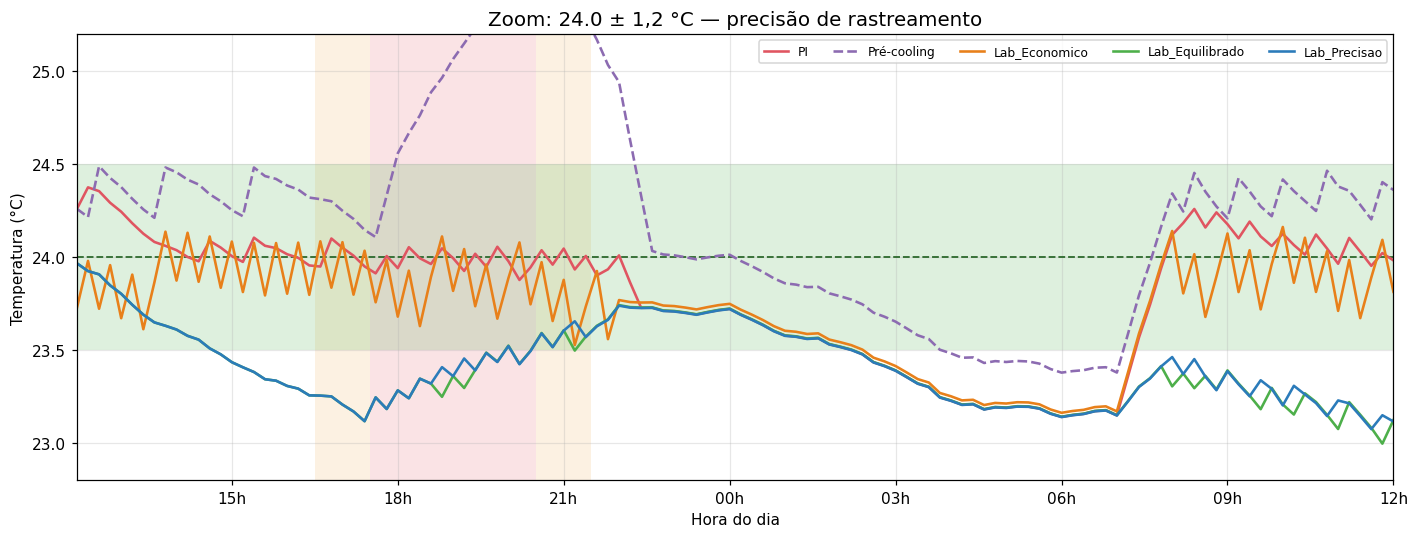

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
faixas_tarifa(ax, CFG, h0, h1)
ax.axhspan(SETP - TOL, SETP + TOL, color="#4daf4a", alpha=0.18, lw=0)
ax.axhline(SETP, color="#2f6b2f", ls="--", lw=1.2)
for nome, df in traj.items():
    ax.plot(df["hour_float"], df["temperature"], lw=1.7,
            ls="--" if nome == "Pré-cooling" else "-", color=CORES.get(nome, "#888"), label=nome)
ax.set_ylim(SETP - 1.2, SETP + 1.2)
eixo_hora_do_dia(ax, h0, h1)
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Zoom: {SETP} ± 1,2 °C — precisão de rastreamento", fontsize=13)
ax.legend(fontsize=8, ncol=5)
fig.tight_layout(); fig.savefig(f"{SAVE}/fig2_zoom_tolerancia.png"); plt.show()

## 3. Deslocamento de carga — a potência sai do posto de ponta?

Painel inferior: potência elétrica. Uma política antecipatória mostra **potência
alta antes de 17h30 e próxima de zero dentro da faixa vermelha**.


/tmp/ipykernel_538725/648215927.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(f"{SAVE}/fig3_potencia_vs_tarifa.png"); plt.show()


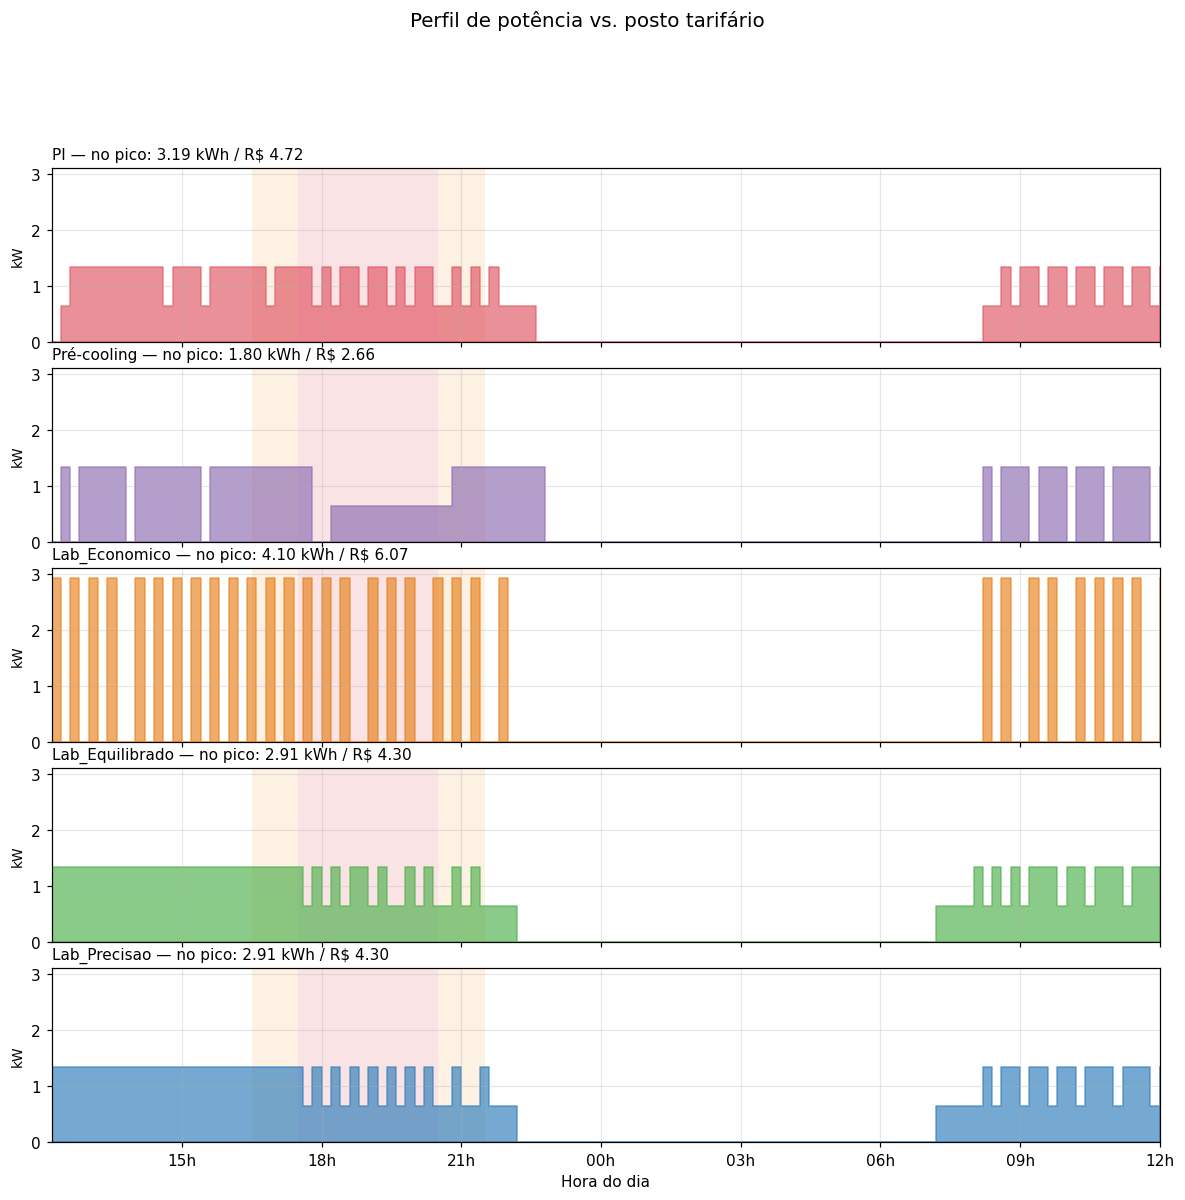

In [4]:
n = len(traj)
fig, axes = plt.subplots(n, 1, figsize=(13, 2.3*n), sharex=True,
                         gridspec_kw={"hspace": 0.15})
axes = np.atleast_1d(axes)
for ax, (nome, df) in zip(axes, traj.items()):
    faixas_tarifa(ax, CFG, h0, h1)
    ax.fill_between(df["hour_float"], 0, df["electrical_kw"], step="post",
                    color=CORES.get(nome, "#888"), alpha=0.65)
    kwh_ponta = df[df["posto"] == "ponta"]["energy_kwh"].sum()
    custo_ponta = df[df["posto"] == "ponta"]["cost_brl"].sum()
    ax.set_ylabel("kW", fontsize=9)
    ax.set_title(f"{nome} — no pico: {kwh_ponta:.2f} kWh / R$ {custo_ponta:.2f}",
                 fontsize=10, loc="left")
    ax.set_ylim(0, 3.1)
eixo_hora_do_dia(axes[-1], h0, h1)
axes[-1].set_xlabel("Hora do dia")
fig.suptitle("Perfil de potência vs. posto tarifário", y=1.005, fontsize=13)
fig.tight_layout(); fig.savefig(f"{SAVE}/fig3_potencia_vs_tarifa.png"); plt.show()

## 4. Custo acumulado — onde o dinheiro é gasto

A inclinação da curva dentro da faixa vermelha é o custo do posto de ponta.


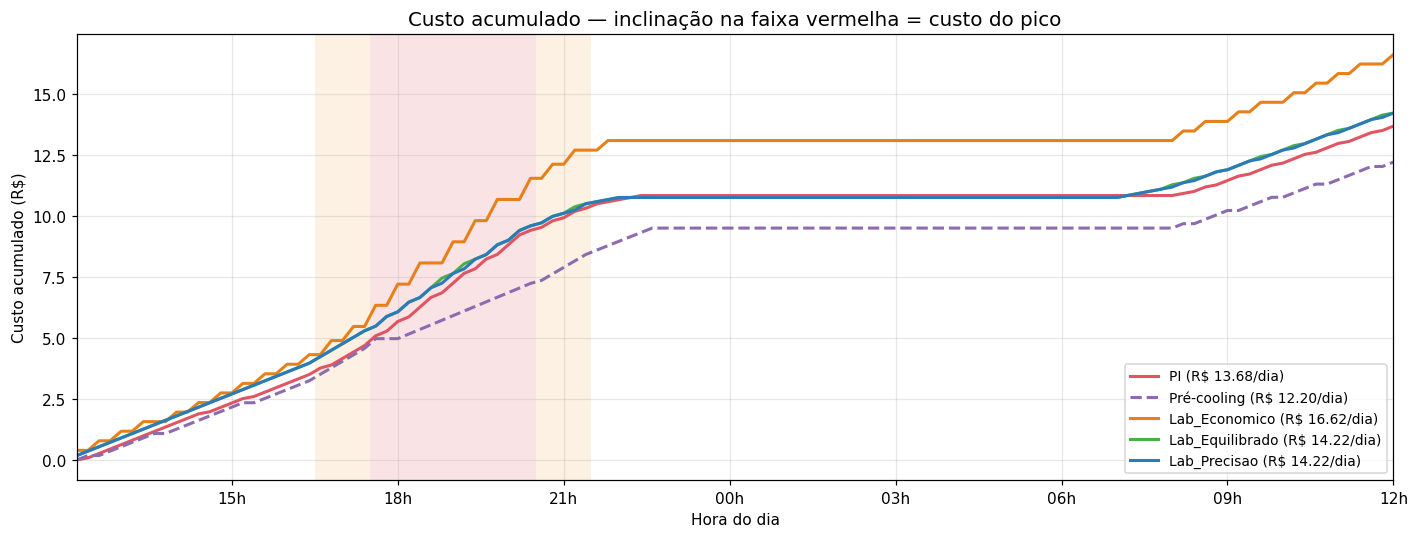

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
faixas_tarifa(ax, CFG, h0, h1)
for nome, df in traj.items():
    ax.plot(df["hour_float"], df["cost_brl"].cumsum(), lw=2.0,
            ls="--" if nome == "Pré-cooling" else "-", color=CORES.get(nome, "#888"),
            label=f"{nome} (R$ {df['cost_brl'].sum():.2f}/dia)")
eixo_hora_do_dia(ax, h0, h1)
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Custo acumulado (R$)")
ax.set_title("Custo acumulado — inclinação na faixa vermelha = custo do pico", fontsize=13)
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(f"{SAVE}/fig4_custo_acumulado.png"); plt.show()

## 5. Distribuição do erro de rastreamento

Violino + boxplot do desvio em relação ao setpoint. Um laboratório especifica
**dispersão**, não média.


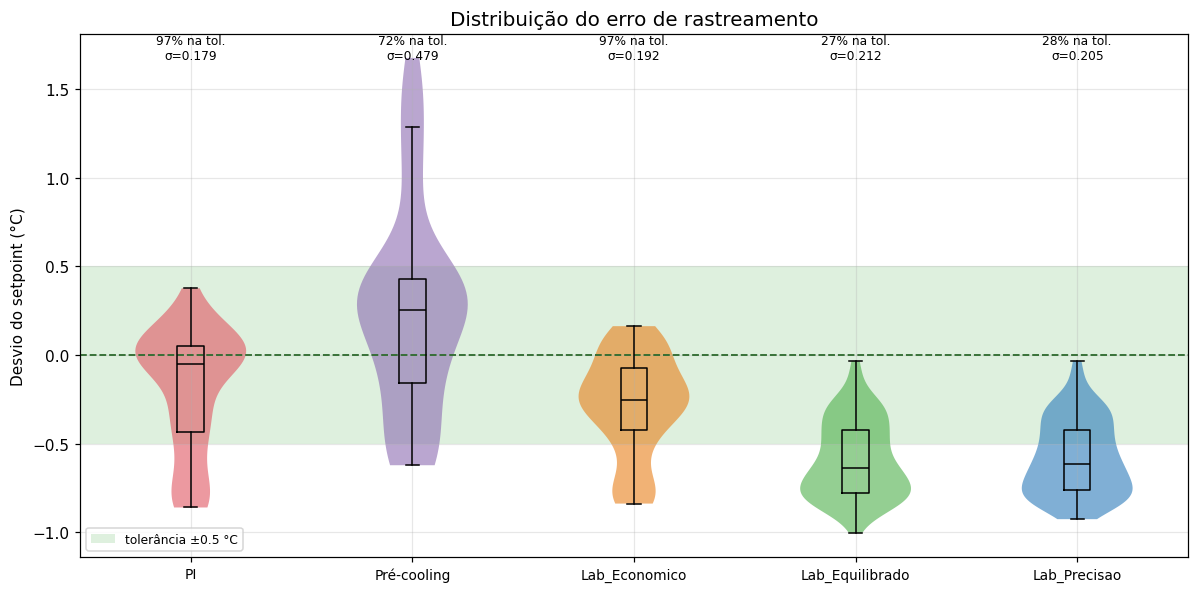

In [6]:
nomes = list(traj); dados = [(traj[n]["temperature"] - SETP).to_numpy() for n in nomes]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axhspan(-TOL, TOL, color="#4daf4a", alpha=0.18, lw=0, label=f"tolerância ±{TOL} °C")
ax.axhline(0, color="#2f6b2f", ls="--", lw=1.2)
parts = ax.violinplot(dados, showextrema=False)
for b, n in zip(parts["bodies"], nomes):
    b.set_facecolor(CORES.get(n, "#888")); b.set_alpha(0.6)
ax.boxplot(dados, widths=0.12, showfliers=False, medianprops={"color": "black"})
for i, n in enumerate(nomes, 1):
    m = episode_metrics(traj[n], cfgs[n])
    ax.text(i, ax.get_ylim()[1], f"{m['in_tolerance_pct']:.0f}% na tol.\nσ={m['temp_std']:.3f}",
            ha="center", va="top", fontsize=8)
ax.set_xticks(range(1, len(nomes)+1)); ax.set_xticklabels(nomes, fontsize=9)
ax.set_ylabel("Desvio do setpoint (°C)")
ax.set_title("Distribuição do erro de rastreamento", fontsize=13)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); fig.savefig(f"{SAVE}/fig5_distribuicao_erro.png"); plt.show()

## 6. A fronteira real: precisão × custo no pico

Este é o plano em que o problema de laboratório vive. **Canto superior esquerdo =
ideal** (alta precisão, custo baixo no pico). Diferente da Figura 3 do paper, aqui
há trade-off de verdade.


,controlador,na_tolerancia_%,sigma,|T-24|,desvio_max,custo_dia,custo_ponta,kWh_dia,trocas_h
0,PI,97.333,0.179,0.110,0.851,13.680,4.720,15.578,1.667
2,Lab_Economico,97.333,0.192,0.181,0.830,16.617,6.072,18.757,2.625
1,Pré-cooling,72.000,0.479,0.561,1.674,12.204,2.662,14.857,0.917
4,Lab_Precisao,28.000,0.205,0.594,0.925,14.215,4.300,16.655,1.458
3,Lab_Equilibrado,26.667,0.212,0.611,1.003,14.215,4.300,16.655,1.417


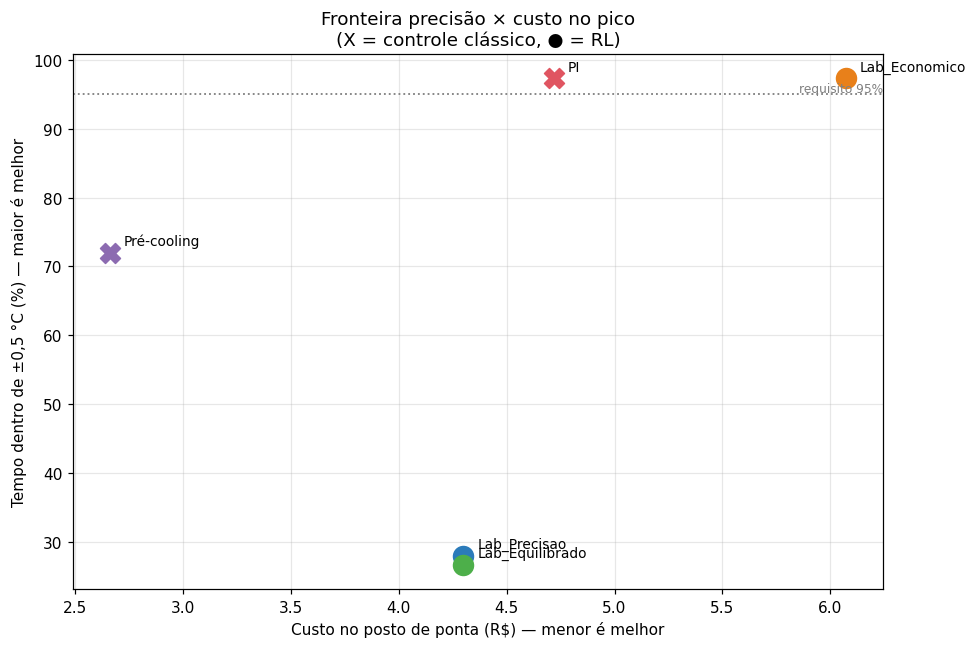

In [7]:
rows = []
for n, df in traj.items():
    m = episode_metrics(df, cfgs[n])
    rows.append({"controlador": n, "na_tolerancia_%": m["in_tolerance_pct"],
                 "sigma": m["temp_std"], "|T-24|": m["abs_dev_from_ideal"],
                 "desvio_max": m["max_abs_dev"], "custo_dia": m["cost_brl_day"],
                 "custo_ponta": m["peak_cost_brl"], "kWh_dia": m["energy_kwh_day"],
                 "trocas_h": m["changes_per_hour"]})
tab = pd.DataFrame(rows).round(3).sort_values("na_tolerancia_%", ascending=False)
display(tab)

fig, ax = plt.subplots(figsize=(9, 6))
for _, r in tab.iterrows():
    clas = r.controlador in ("PI", "Pré-cooling")
    ax.scatter(r.custo_ponta, r["na_tolerancia_%"], s=170,
               marker="X" if clas else "o", color=CORES.get(r.controlador, "#888"), zorder=3)
    ax.annotate(r.controlador, (r.custo_ponta, r["na_tolerancia_%"]),
                textcoords="offset points", xytext=(9, 5), fontsize=9)
ax.axhline(95, color="gray", ls=":", lw=1.2)
ax.text(ax.get_xlim()[1], 95.4, "requisito 95%", ha="right", fontsize=8, color="gray")
ax.set_xlabel("Custo no posto de ponta (R$) — menor é melhor")
ax.set_ylabel("Tempo dentro de ±0,5 °C (%) — maior é melhor")
ax.set_title("Fronteira precisão × custo no pico\n(X = controle clássico, ● = RL)", fontsize=12)
fig.tight_layout(); fig.savefig(f"{SAVE}/fig6_fronteira_precisao_custo.png"); plt.show()

## 7. Leitura

Critério de sucesso: um perfil de RraL **acima da linha de 95 %** e **à esquerda do
PI** capturou economia que o controle clássico não alcança — o PI não conhece o
preço, então não pode antecipar por construção.

Se todos os pontos de RL ficarem à direita ou abaixo do PI, a conclusão honesta é
que o PI é a resposta certa para este problema, e mais barata de implantar.

Para refazer com mais sementes: `python train.py --lab --timesteps 550000 --seeds 0 1 2`.
